In [2]:
import numpy as np
import json
import os

import warnings
warnings.filterwarnings(action="ignore")

In [7]:
DS_PATH = "../data/golos_opus/test_opus/crowd"

In [20]:
def load_jsonl(path: str) -> list[str]:
    data = []
    with open(path, 'r') as file:
        for line in file:
            line = line.strip()
            if line:
                res = json.loads(line)
                data.append(res)

    print(f"Loaded {len(crowd_data)} JSON's\n===\n{crowd_data[0]}")
    return data

In [25]:
crowd_data = load_jsonl(os.path.join(DS_PATH, "crowd.jsonl"))
print("!хз какая разница")
manifest_data = load_jsonl(os.path.join(DS_PATH, "manifest.jsonl"))

Loaded 9994 JSON's
===
{'id': 'e632f7d39c15e7edfc665b91e6f2071f', 'audio_filepath': 'files/e632f7d39c15e7edfc665b91e6f2071f.opus', 'text': 'афина воспроизведи музыку вперемешку', 'duration': 4.9}
!хз какая разница
Loaded 9994 JSON's
===
{'id': 'e632f7d39c15e7edfc665b91e6f2071f', 'audio_filepath': 'files/e632f7d39c15e7edfc665b91e6f2071f.opus', 'text': 'афина воспроизведи музыку вперемешку', 'duration': 4.9}


In [26]:
import librosa

In [45]:
sample_audio = crowd_data[0]
sample_path = os.path.join(DS_PATH, sample_audio["audio_filepath"])
waveform, sample_rate = librosa.load(sample_path, sr=16000)
NYQUIST_CONST = 8000

print(f"Length of loaded audio: {len(waveform) / sample_rate:.2f}, JSON data: {sample_audio["duration"]}")

Length of loaded audio: 4.90, JSON data: 4.9


In [34]:
from matplotlib import pyplot as plt

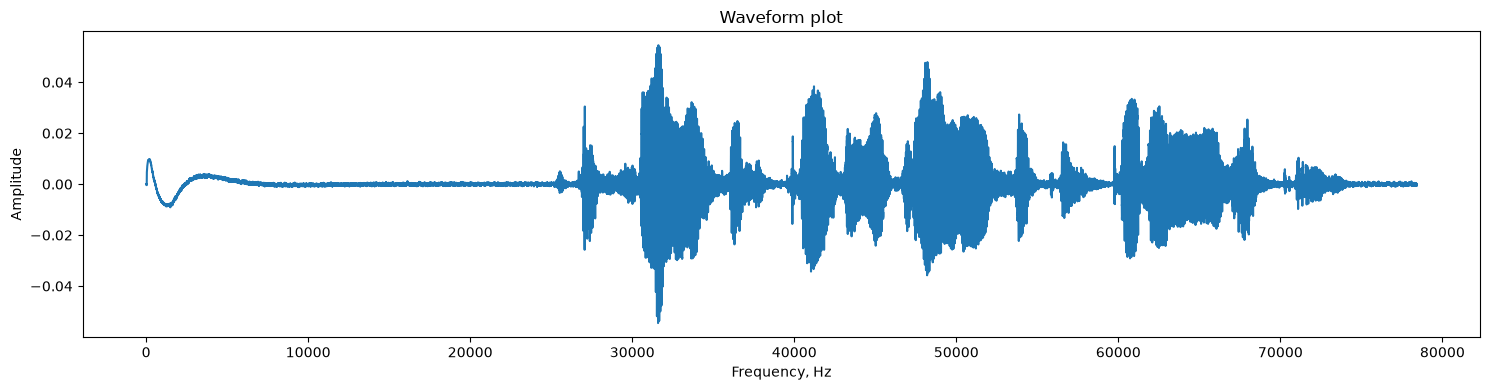

In [41]:
fig = plt.figure(figsize=(15, 4))
plt.plot(waveform)

plt.title("Waveform plot")
plt.xlabel("Frequency, Hz")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

mfcc (mel-frequency cepstral coefficients)

In [32]:
mfccs = librosa.feature.mfcc(y=waveform, sr=sample_rate, n_mfcc=13) #13 по умолчанию берут

log mel-spectrogram

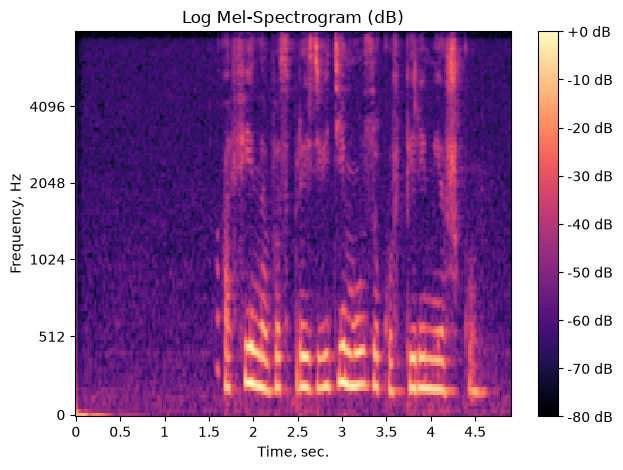

In [50]:
mel_spec = librosa.feature.melspectrogram(y=waveform, sr=sample_rate, n_fft=1024, hop_length=256, n_mels=128, fmax=NYQUIST_CONST)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

librosa.display.specshow(
    log_mel_spec,
    sr=sample_rate,
    hop_length=256,
    x_axis='time',
    y_axis='mel',
    fmax=NYQUIST_CONST,
    cmap='magma',
)

plt.colorbar(format="%+2.0f dB")
plt.title("Log Mel-Spectrogram (dB)")
plt.xlabel("Time, sec.")
plt.ylabel("Frequency, Hz")

plt.tight_layout()
plt.show()